

---

HELP LIB


---



In [ ]:
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

def plot_some_data(train_images, train_labels, class_names):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(train_images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[train_labels[i]])
    plt.show()


def plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3):
    # Plot the first X test images, their predicted labels, and the true labels.
    # Color correct predictions in blue and incorrect predictions in red.
    num_images = num_rows*num_cols
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))
    for i in range(num_images):
        plt.subplot(num_rows, 2*num_cols, 2*i+1)
        plot_image(i, predictions[i], test_labels, class_names, test_images)
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        plot_value_array(i, predictions[i], test_labels)
    plt.tight_layout()
    plt.show()




def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

def plot_image(i, predictions_array, true_label, class_names, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)




---

ADAMAX ALGORITHM

---



4422102/4422102 [==============================] - 0s 0us/step


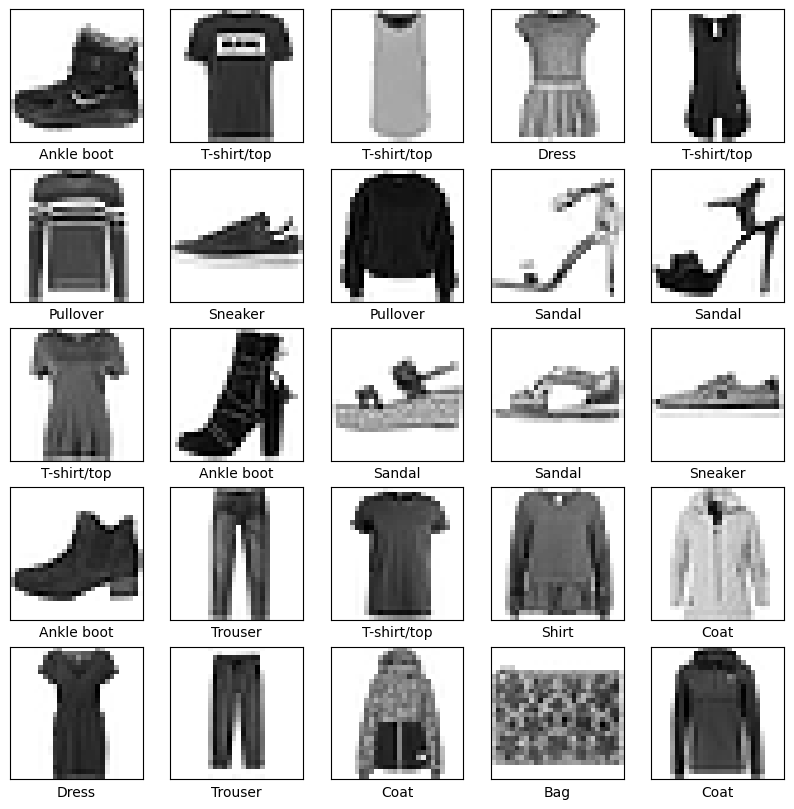

Epoch 1/400
1875/1875 [==============================] - 13s 6ms/step - loss: 0.5488 - accuracy: 0.8134 - val_loss: 0.4904 - val_accuracy: 0.8284
Epoch 2/400
1875/1875 [==============================] - 11s 6ms/step - loss: 0.4204 - accuracy: 0.8537 - val_loss: 0.4383 - val_accuracy: 0.8455
Epoch 3/400
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3856 - accuracy: 0.8654 - val_loss: 0.4008 - val_accuracy: 0.8573
Epoch 4/400
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3636 - accuracy: 0.8711 - val_loss: 0.3964 - val_accuracy: 0.8598
Epoch 5/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3446 - accuracy: 0.8764 - val_loss: 0.3833 - val_accuracy: 0.8621
Epoch 6/400
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3305 - accuracy: 0.8824 - val_loss: 0.3674 - val_accuracy: 0.8700
Epoch 7/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3188 - accuracy: 0.8853 - val_loss: 0.3857 - val_

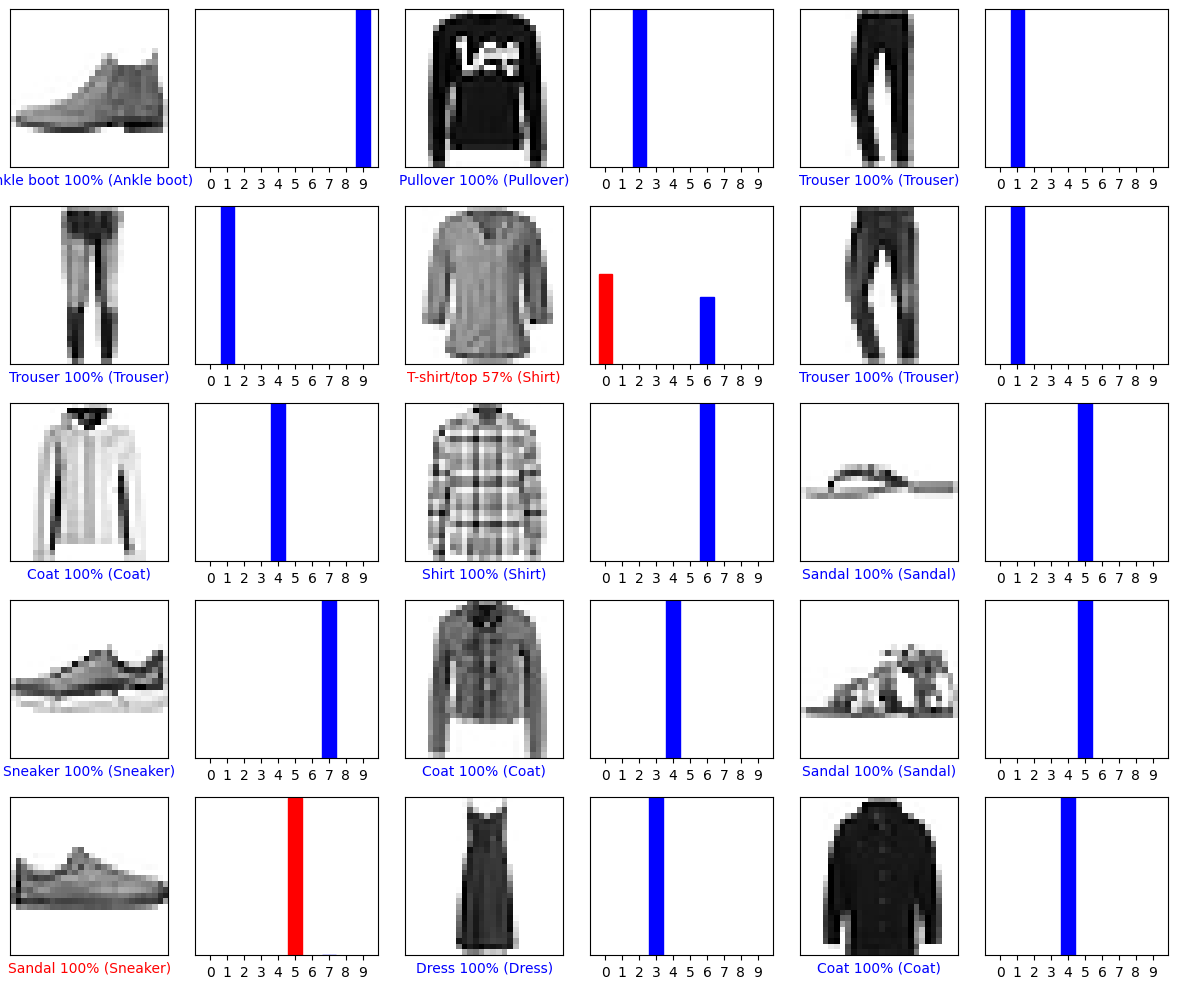

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Scale these values to a range of 0 to 1 before feeding them to the neural network model.
    ### YOUR CODE HERE

train_images = train_images / 255.0
test_images = test_images / 255.0

plot_some_data(train_images, train_labels, class_names)

# Build the model of dense neural network
# Building the neural network requires configuring the layers of the model, then compiling the model.
# Define the input layer based on the shape of the images
# Then define two dense layers.
# The hidden layer with 128 neurons and RELU activation
# The output layer with 10 neurons and linear activation.

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)

])


model.compile(optimizer='adamax',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#Train the model
# Training the neural network model requires the following steps:

#   1. Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
#   2. The model learns to associate images and labels.
#   3. You ask the model to make predictions about a test set—in this example, the test_images array.
#   4. Verify that the predictions match the labels from the test_labels array.

model.fit(train_images, train_labels, epochs=400, validation_data=(test_images, test_labels))

# Evaluate accuracy
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

# Make predictions
# With the model trained, you can use it to make predictions about some images.
# The model's linear outputs, logits.
# Attach a softmax layer to convert the logits to probabilities, which are easier to interpret.
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images)

plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3)




---

FTRL

---



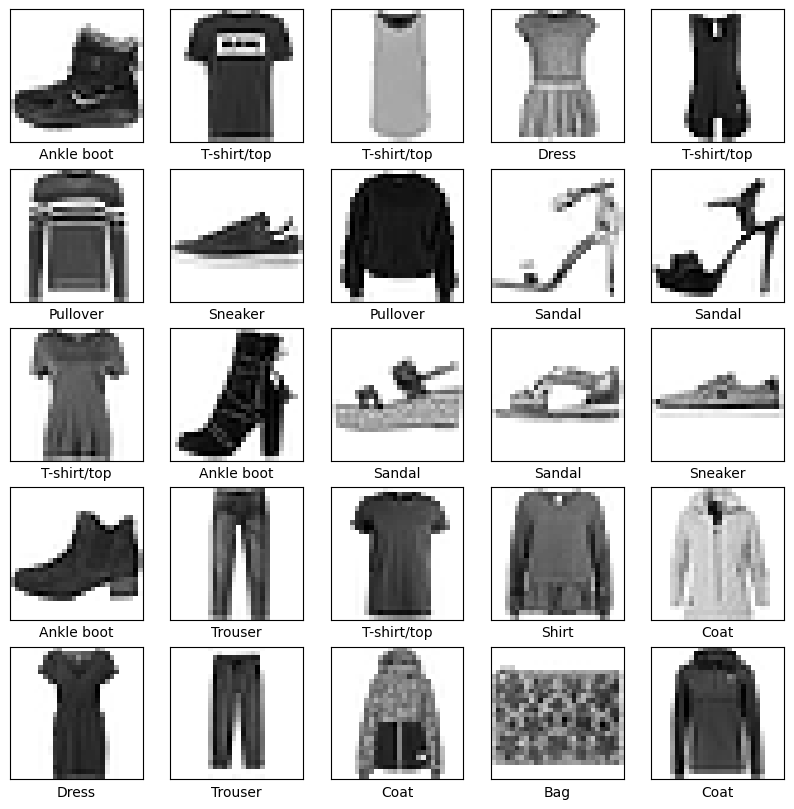

Epoch 1/400
1875/1875 [==============================] - 9s 4ms/step - loss: 2.2533 - accuracy: 0.1500 - val_loss: 2.0625 - val_accuracy: 0.2283
Epoch 2/400
1875/1875 [==============================] - 9s 5ms/step - loss: 1.7337 - accuracy: 0.3508 - val_loss: 1.5166 - val_accuracy: 0.4283
Epoch 3/400
1875/1875 [==============================] - 9s 5ms/step - loss: 1.3979 - accuracy: 0.4469 - val_loss: 1.3076 - val_accuracy: 0.4836
Epoch 4/400
1875/1875 [==============================] - 9s 5ms/step - loss: 1.2205 - accuracy: 0.5613 - val_loss: 1.1538 - val_accuracy: 0.6018
Epoch 5/400
1875/1875 [==============================] - 10s 5ms/step - loss: 1.0812 - accuracy: 0.6161 - val_loss: 1.0354 - val_accuracy: 0.6213
Epoch 6/400
1875/1875 [==============================] - 9s 5ms/step - loss: 0.9811 - accuracy: 0.6421 - val_loss: 0.9552 - val_accuracy: 0.6449
Epoch 7/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.9133 - accuracy: 0.6597 - val_loss: 0.9006 - val_a

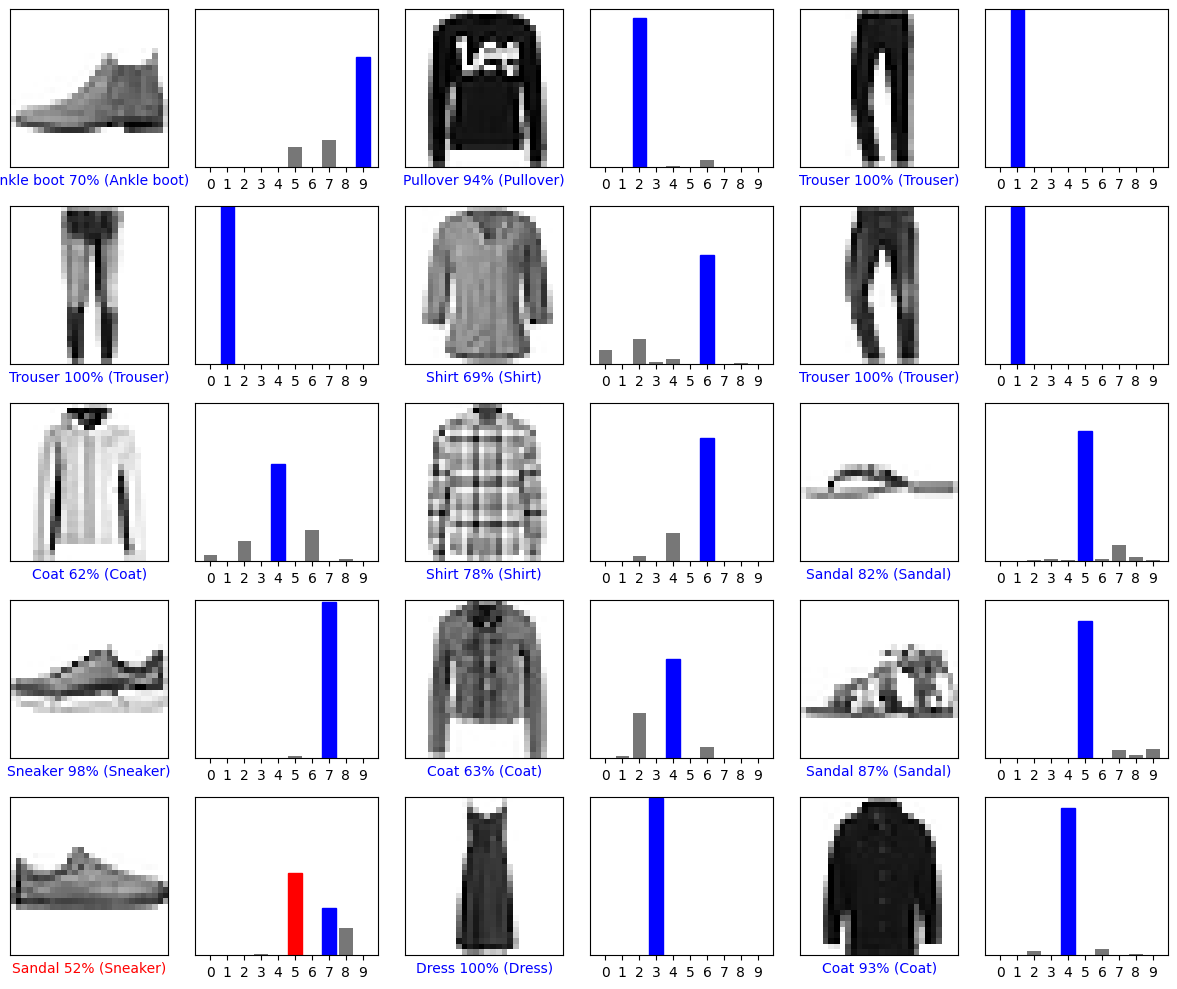

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Scale these values to a range of 0 to 1 before feeding them to the neural network model.
    ### YOUR CODE HERE

train_images = train_images / 255.0
test_images = test_images / 255.0

plot_some_data(train_images, train_labels, class_names)

# Build the model of dense neural network
# Building the neural network requires configuring the layers of the model, then compiling the model.
# Define the input layer based on the shape of the images
# Then define two dense layers.
# The hidden layer with 128 neurons and RELU activation
# The output layer with 10 neurons and linear activation.

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)

])


model.compile(optimizer='ftrl',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#Train the model
# Training the neural network model requires the following steps:

#   1. Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
#   2. The model learns to associate images and labels.
#   3. You ask the model to make predictions about a test set—in this example, the test_images array.
#   4. Verify that the predictions match the labels from the test_labels array.

model.fit(train_images, train_labels, epochs=400, validation_data=(test_images, test_labels))

# Evaluate accuracy
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

# Make predictions
# With the model trained, you can use it to make predictions about some images.
# The model's linear outputs, logits.
# Attach a softmax layer to convert the logits to probabilities, which are easier to interpret.
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images)

plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3)




---

NADAM ALGORITHM

---



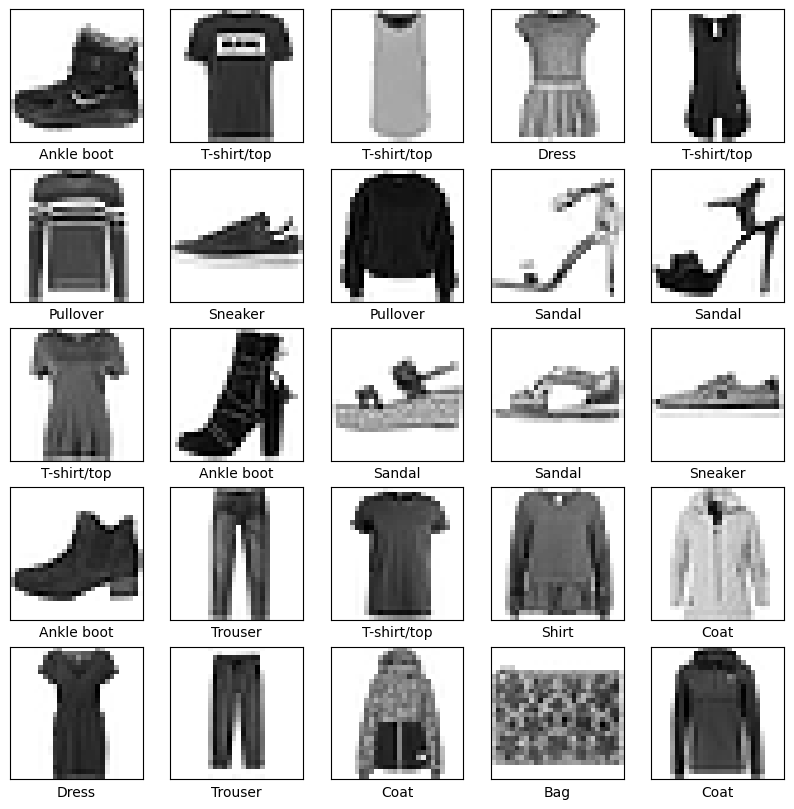

Epoch 1/400
1875/1875 [==============================] - 9s 4ms/step - loss: 0.4837 - accuracy: 0.8309 - val_loss: 0.4291 - val_accuracy: 0.8457
Epoch 2/400
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3695 - accuracy: 0.8674 - val_loss: 0.3834 - val_accuracy: 0.8647
Epoch 3/400
1875/1875 [==============================] - 10s 6ms/step - loss: 0.3314 - accuracy: 0.8799 - val_loss: 0.3868 - val_accuracy: 0.8619
Epoch 4/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3078 - accuracy: 0.8877 - val_loss: 0.3595 - val_accuracy: 0.8719
Epoch 5/400
1875/1875 [==============================] - 10s 5ms/step - loss: 0.2910 - accuracy: 0.8926 - val_loss: 0.3412 - val_accuracy: 0.8769
Epoch 6/400
1875/1875 [==============================] - 11s 6ms/step - loss: 0.2779 - accuracy: 0.8975 - val_loss: 0.3404 - val_accuracy: 0.8776
Epoch 7/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2642 - accuracy: 0.9025 - val_loss: 0.3456 - va

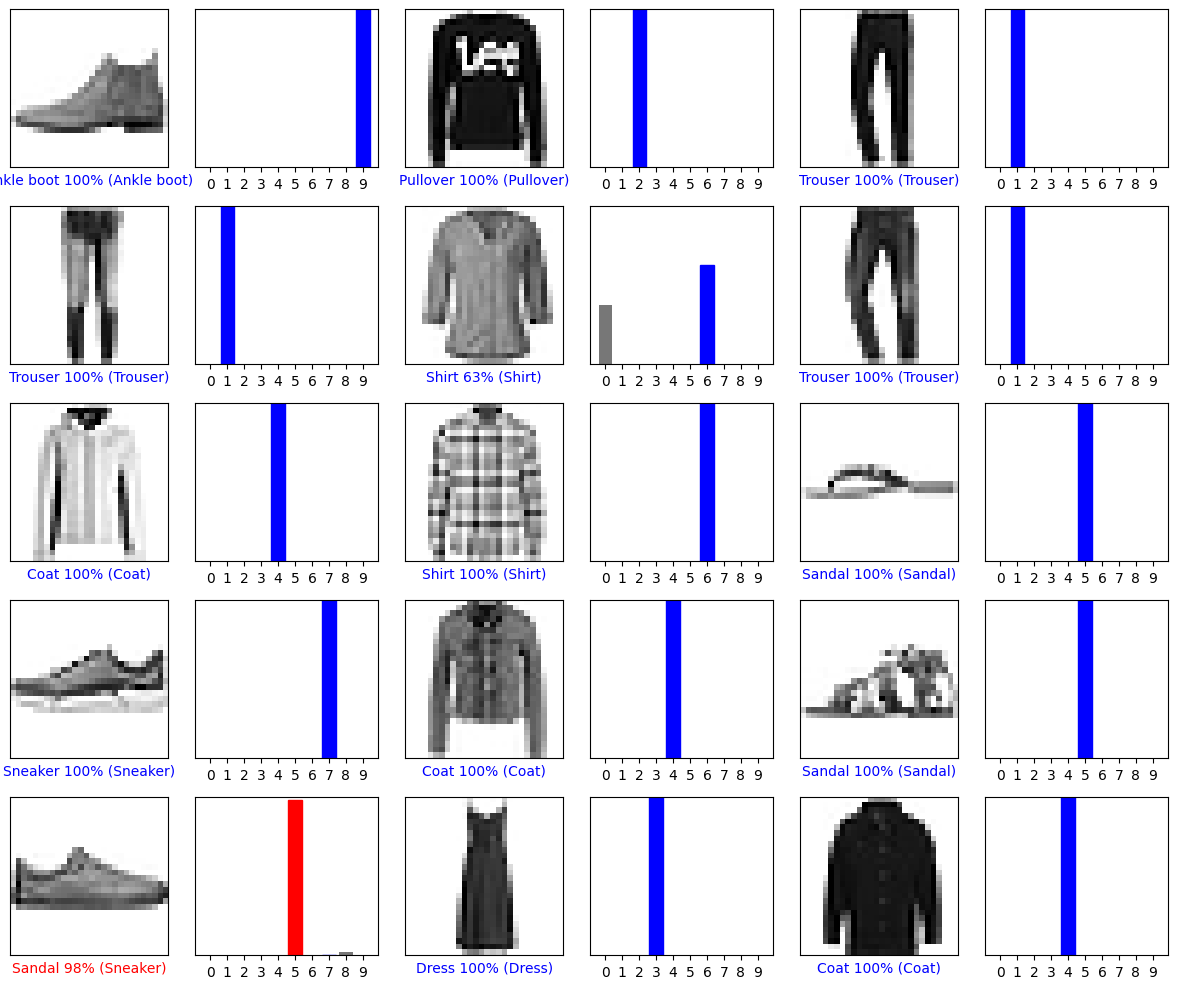

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Scale these values to a range of 0 to 1 before feeding them to the neural network model.
    ### YOUR CODE HERE

train_images = train_images / 255.0
test_images = test_images / 255.0

plot_some_data(train_images, train_labels, class_names)

# Build the model of dense neural network
# Building the neural network requires configuring the layers of the model, then compiling the model.
# Define the input layer based on the shape of the images
# Then define two dense layers.
# The hidden layer with 128 neurons and RELU activation
# The output layer with 10 neurons and linear activation.

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)

])


model.compile(optimizer='nadam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#Train the model
# Training the neural network model requires the following steps:

#   1. Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
#   2. The model learns to associate images and labels.
#   3. You ask the model to make predictions about a test set—in this example, the test_images array.
#   4. Verify that the predictions match the labels from the test_labels array.

model.fit(train_images, train_labels, epochs=400, validation_data=(test_images, test_labels))

# Evaluate accuracy
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

# Make predictions
# With the model trained, you can use it to make predictions about some images.
# The model's linear outputs, logits.
# Attach a softmax layer to convert the logits to probabilities, which are easier to interpret.
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images)

plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3)




---

ADAM ALGORITHM

---

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Scale these values to a range of 0 to 1 before feeding them to the neural network model.
    ### YOUR CODE HERE

train_images = train_images / 255.0
test_images = test_images / 255.0

plot_some_data(train_images, train_labels, class_names)

# Build the model of dense neural network
# Building the neural network requires configuring the layers of the model, then compiling the model.
# Define the input layer based on the shape of the images
# Then define two dense layers.
# The hidden layer with 128 neurons and RELU activation
# The output layer with 10 neurons and linear activation.

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)

])


model.compile(optimizer='adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#Train the model
# Training the neural network model requires the following steps:

#   1. Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
#   2. The model learns to associate images and labels.
#   3. You ask the model to make predictions about a test set—in this example, the test_images array.
#   4. Verify that the predictions match the labels from the test_labels array.

model.fit(train_images, train_labels, epochs=400, validation_data=(test_images, test_labels))

# Evaluate accuracy
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

# Make predictions
# With the model trained, you can use it to make predictions about some images.
# The model's linear outputs, logits.
# Attach a softmax layer to convert the logits to probabilities, which are easier to interpret.
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images)

plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3)




---

Μερικές εκτελέσεις βρίσκονται σε άλλα αρχεία και κάποιες δεν υπάρχουν γιατί
είναι αρκετά παρόμοιες με εκτελέσεις παραπάνω.


---


